# KDE Comparison: Real vs Synthetic (Electric Vehicles)

Compare kernel density estimates for sparse numerical columns across 4 generative models.

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# --- Data paths ---
RESULTS = Path("../results/electric_vehicles")
REAL_PATH = RESULTS / "data" / "train.jsonl"
SYNTH_PATHS = {
    "REalTabF.": RESULTS / "realtabformer" / "samples" / "synthetic_1.jsonl",
    "Tab.ARGN": RESULTS / "mostlyai" / "samples" / "synthetic_1.jsonl",
    "TabDiff": RESULTS / "tabdiff" / "samples" / "synthetic_1.jsonl",
    "Origami": RESULTS / "origami" / "samples" / "synthetic_1.jsonl",
}

COLUMNS = ["Maximum Gross Weight", "Passengers", "Unladen Weight"]
MODEL_ORDER = ["REalTabF.", "Tab.ARGN", "TabDiff", "Origami"]


def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]


# Load data
real_records = load_jsonl(REAL_PATH)
real_df = pd.DataFrame(real_records)

synth_dfs = {}
for name, path in SYNTH_PATHS.items():
    synth_dfs[name] = pd.DataFrame(load_jsonl(path))

print(f"Real: {len(real_df)} rows")
for name, df in synth_dfs.items():
    print(f"{name}: {len(df)} rows")

Real: 189010 rows
REalTabF.: 189010 rows
Tab.ARGN: 189010 rows
TabDiff: 189010 rows
Origami: 189010 rows


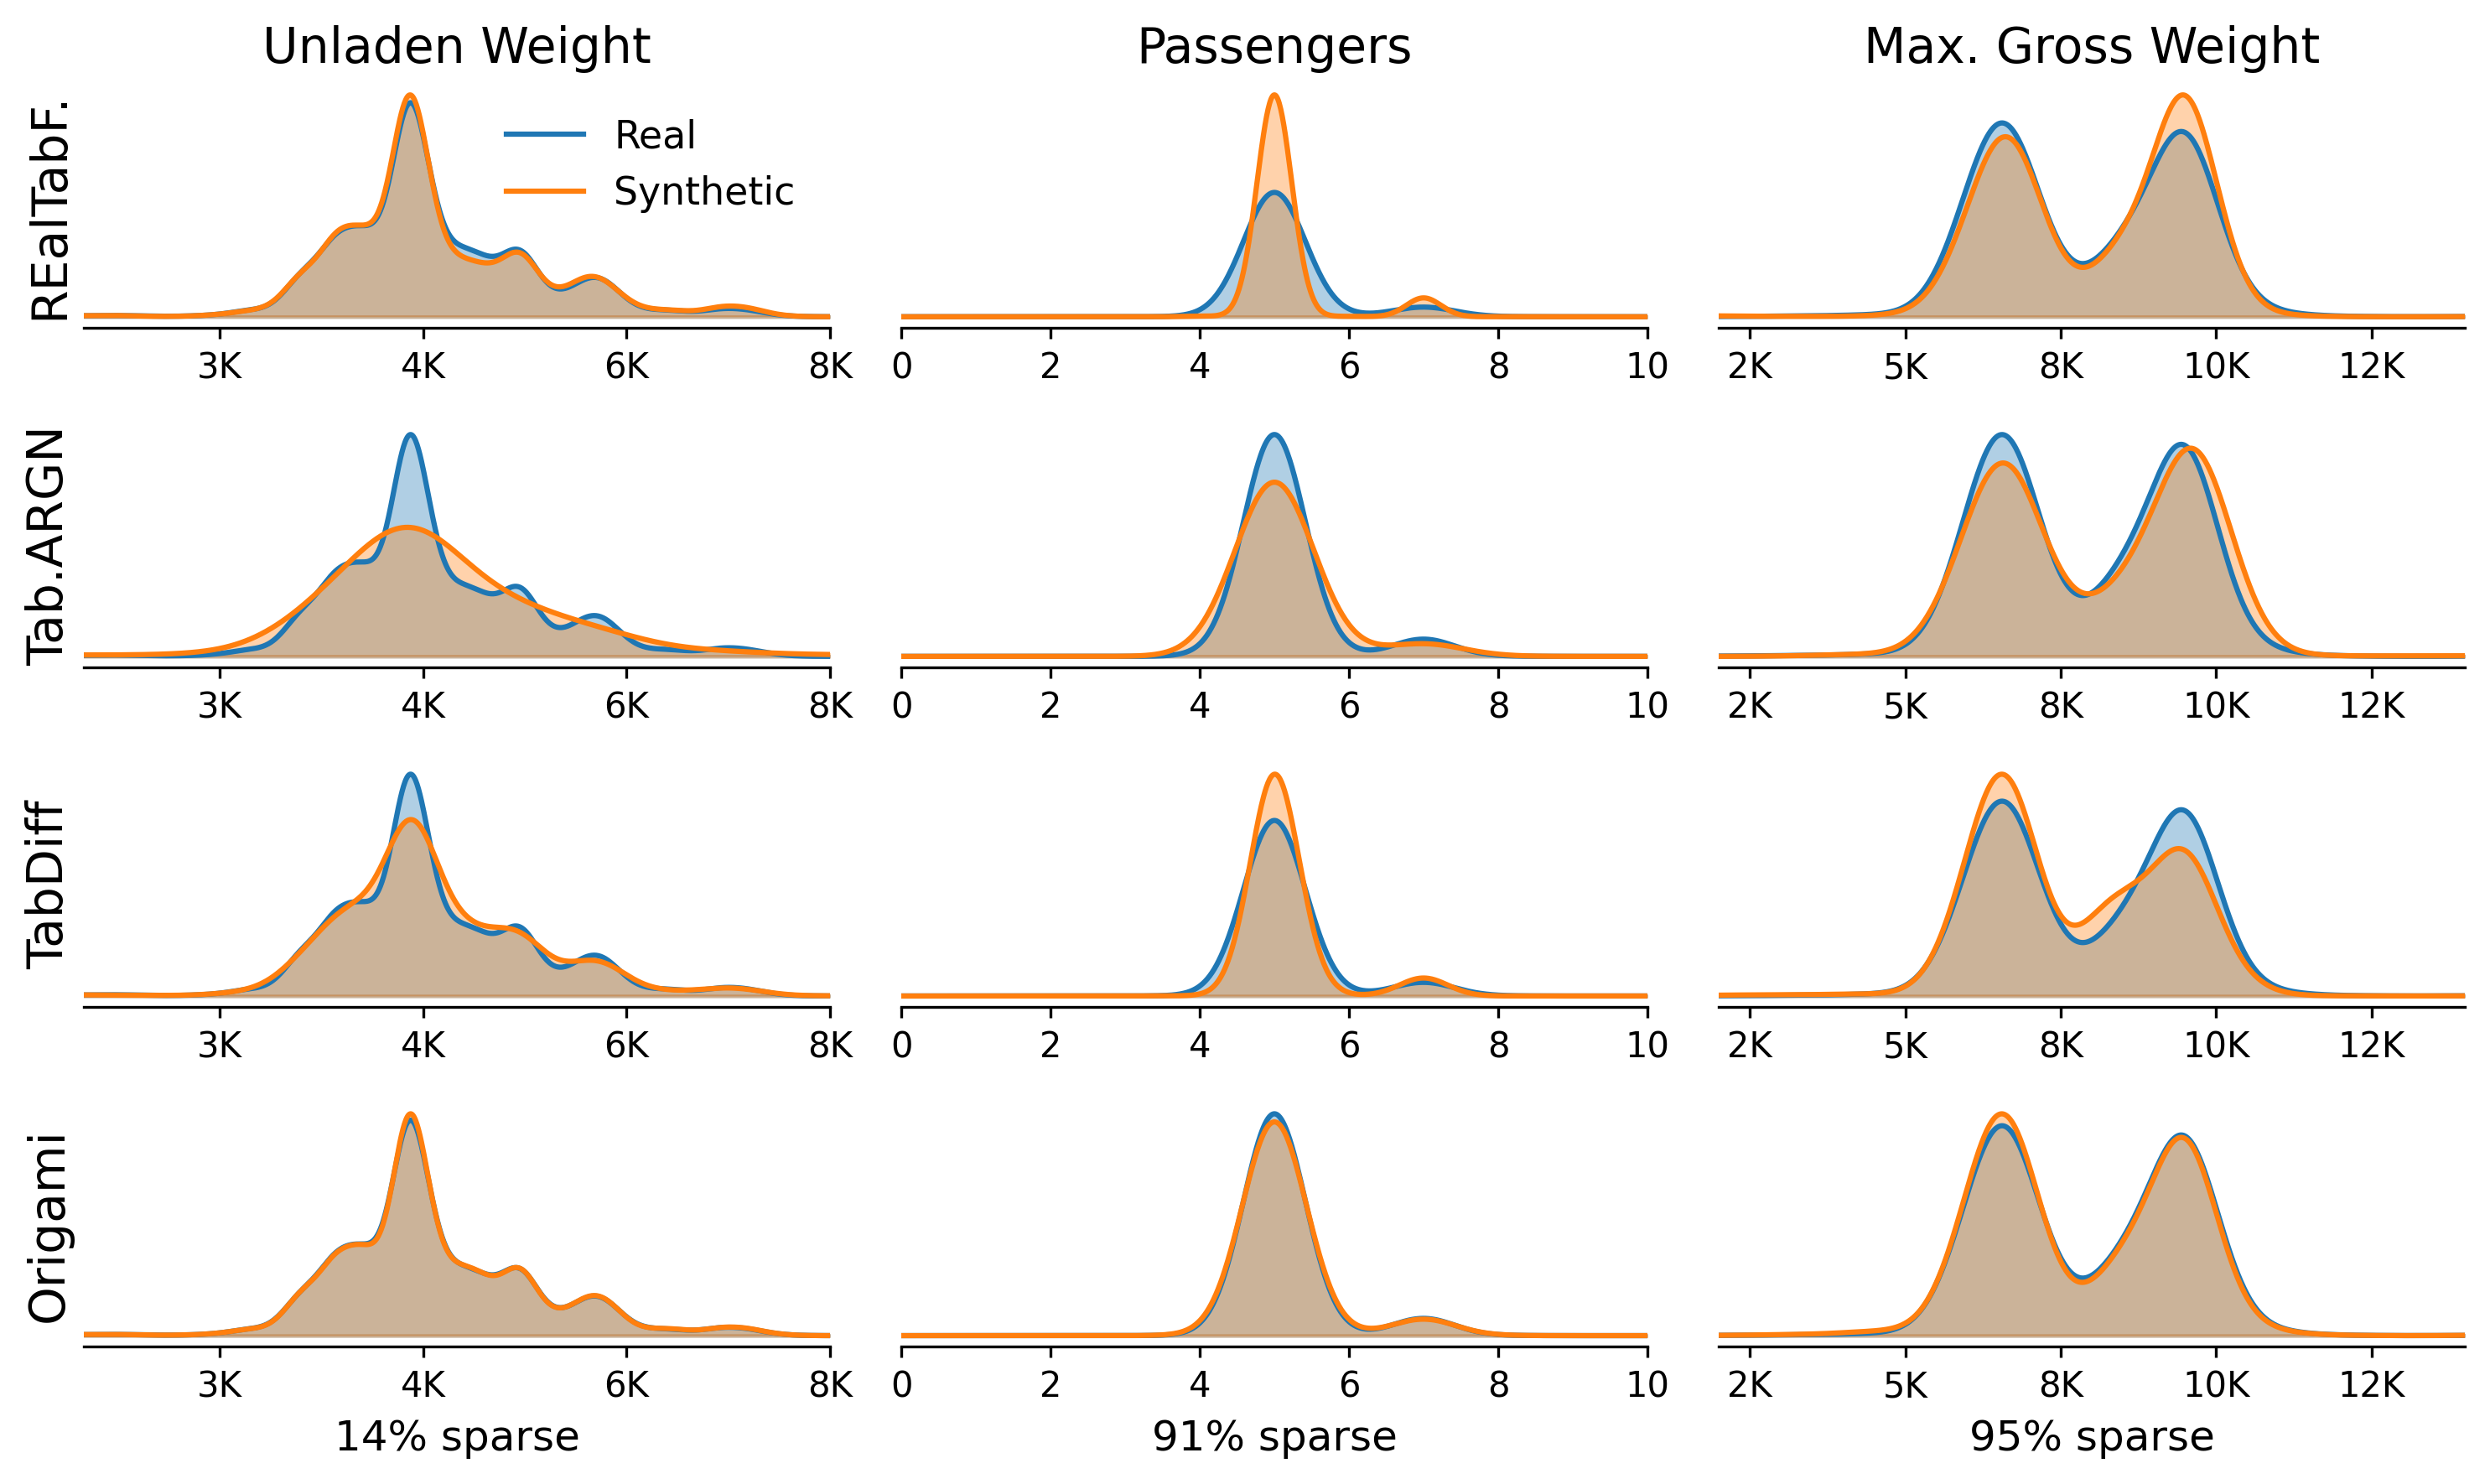

In [2]:
from matplotlib.ticker import FuncFormatter, MaxNLocator

# Paper
COLOR_REAL = "#1f77b4"
COLOR_SYNTH = "#ff7f0e"

# Blog post
# COLOR_REAL = "#0D9488"
# COLOR_SYNTH = "#F2A74B"

fig, axes = plt.subplots(len(MODEL_ORDER), len(COLUMNS), figsize=(10, 6), dpi=300)

# Fixed x-axis limits per column
XLIMS = {
    "Unladen Weight": (2000, 7500),
    "Maximum Gross Weight": (2000, 14000),
    "Passengers": (0, 10),
}

# Column display names
COL_TITLES = {
    "Maximum Gross Weight": "Max. Gross Weight",
    "Passengers": "Passengers",
    "Unladen Weight": "Unladen Weight",
}

for row, model in enumerate(MODEL_ORDER):
    synth = synth_dfs[model]
    for col_idx, column in enumerate(COLUMNS[::-1]):
        ax = axes[row, col_idx]

        # Extract non-null numeric values
        real_vals = pd.to_numeric(real_df[column], errors="coerce").dropna().values
        synth_vals = pd.to_numeric(synth[column], errors="coerce").dropna().values

        lo, hi = XLIMS[column]
        xs = np.linspace(lo, hi, 1000)

        # KDE
        if len(real_vals) > 1:
            kde_real = gaussian_kde(real_vals)
            ax.fill_between(xs, kde_real(xs), alpha=0.35, color=COLOR_REAL)
            ax.plot(xs, kde_real(xs), color=COLOR_REAL, lw=1.5, label="Real")

        if len(synth_vals) > 1:
            kde_synth = gaussian_kde(synth_vals)
            ax.fill_between(xs, kde_synth(xs), alpha=0.35, color=COLOR_SYNTH)
            ax.plot(xs, kde_synth(xs), color=COLOR_SYNTH, lw=1.5, label="Synthetic")

        ax.set_xlim(lo, hi)
        ax.set_yticks([])

        # Remove frame but keep bottom x-axis line
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

        # Show x-axis ticks on every plot, at most 5
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.tick_params(axis="x", length=3)

        if row == 0:
            ax.set_title(COL_TITLES[column], fontsize=14)
        if col_idx == 0:
            ax.set_ylabel(model, fontsize=14, rotation=90, labelpad=10, va="center")

        # Sparsity label on bottom row
        if row == len(MODEL_ORDER) - 1:
            sparsity = 1.0 - real_df[column].notna().mean()
            ax.set_xlabel(f"{sparsity:.0%} sparse", fontsize=12)

        # K suffix formatter
        if hi > 1000:
            ax.xaxis.set_major_formatter(
                FuncFormatter(lambda x, _: f"{x / 1000:.0f}K" if x >= 1000 else f"{x:.0f}")
            )

# Legend on top-right subplot
axes[0, 0].legend(fontsize=11, loc="upper right", frameon=False)

plt.tight_layout()
plt.savefig("kde_electric_vehicles.pdf", bbox_inches="tight", dpi=300)
plt.savefig("kde_electric_vehicles.png", bbox_inches="tight", dpi=300, transparent=True)
plt.show()